In [1]:
import copy
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
EUROSAT_PATH="../dataset/EuroSAT"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
dataset = ImageFolder(EUROSAT_PATH)

train_size = int(0.8*len(dataset))
val_size = len(dataset)-train_size

train_subset,val_subset = random_split(
    dataset,
    [train_size,val_size],
    generator=torch.Generator().manual_seed(42)
)

In [6]:
class TransformDataset(Dataset):

    def __init__(self,subset,transform):
        self.subset=subset
        self.transform=transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self,index):

        image,label=self.subset[index]

        image=self.transform(image)

        return image,label

In [7]:
train_dataset=TransformDataset(train_subset,train_transform)
val_dataset=TransformDataset(val_subset,val_transform)

train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader=DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [9]:
weights=models.ResNet18_Weights.DEFAULT

model=models.resnet18(weights=weights)

In [10]:
for param in model.parameters():
    param.requires_grad=False

In [12]:
num_features=model.fc.in_features

model.fc=nn.Linear(
    num_features,
    10
)

model=model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [14]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [15]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=2
)

In [16]:
def train_model(model, train_loader, val_loader,
                criterion, optimizer, scheduler,
                epochs=5):

    best_acc = 0

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    for epoch in range(epochs):

        #####################
        # Training
        #####################

        model.train()

        running_loss = 0

        correct = 0

        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_acc = 100 * correct / total

        #####################
        # Validation
        #####################

        model.eval()

        running_loss = 0

        correct = 0

        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)

        val_acc = 100 * correct / total

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.2f}%")
        print(f"Val Loss   : {val_loss:.4f}")
        print(f"Val Acc    : {val_acc:.2f}%")
        print("-"*50)

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                "../models/resnet18_best.pth"
            )

    return train_losses, val_losses, train_accs, val_accs

In [17]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=5
)

Epoch [1/5]
Train Loss : 0.6906
Train Acc  : 79.53%
Val Loss   : 0.4916
Val Acc    : 83.67%
--------------------------------------------------
Epoch [2/5]
Train Loss : 0.4055
Train Acc  : 86.89%
Val Loss   : 0.3861
Val Acc    : 87.67%
--------------------------------------------------
Epoch [3/5]
Train Loss : 0.3639
Train Acc  : 87.76%
Val Loss   : 0.3338
Val Acc    : 89.57%
--------------------------------------------------
Epoch [4/5]
Train Loss : 0.3384
Train Acc  : 88.47%
Val Loss   : 0.3287
Val Acc    : 89.35%
--------------------------------------------------
Epoch [5/5]
Train Loss : 0.3263
Train Acc  : 88.99%
Val Loss   : 0.3366
Val Acc    : 88.69%
--------------------------------------------------


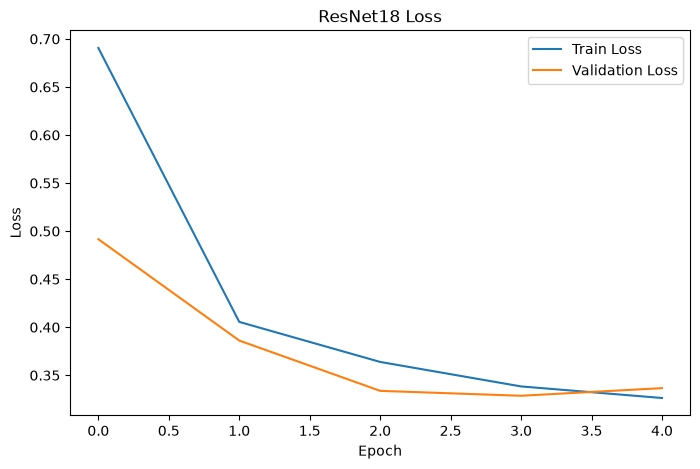

In [18]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss")

plt.legend()

plt.show()

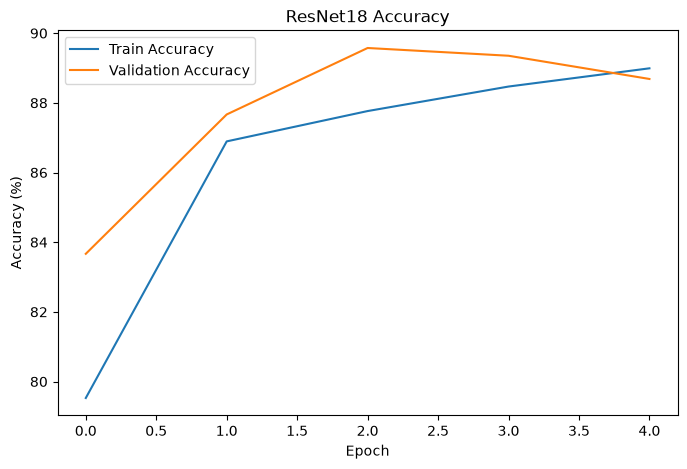

In [19]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,label="Train Accuracy")
plt.plot(val_accs,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 Accuracy")

plt.legend()

plt.show()